In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [65]:
df = pd.read_csv("adm_data.csv")
df. describe()
df.columns = df.columns.str.strip()

In [66]:
y = df['Chance of Admit']
X = df.drop(columns='Chance of Admit')
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1
396,325,107,3,3.0,3.5,9.11,1
397,330,116,4,5.0,4.5,9.45,1
398,312,103,3,3.5,4.0,8.78,0


In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
predictions = model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)

Model R2 Score: 0.8212
Model MSE: 0.0046


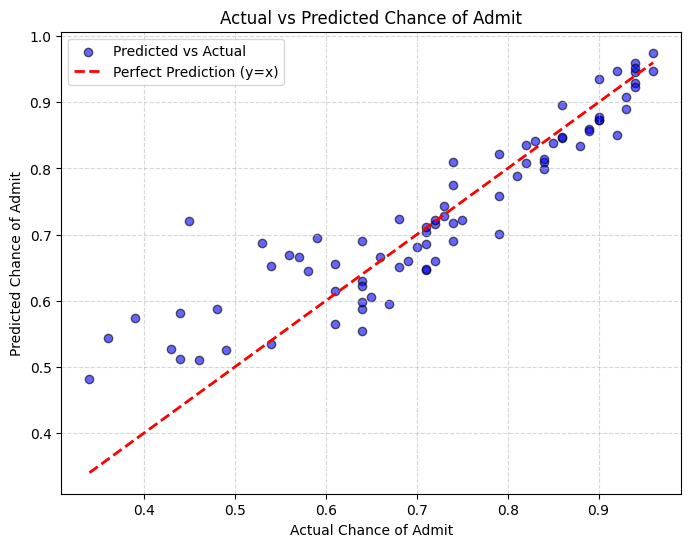

In [69]:
print(f"Model R2 Score: {r2:.4f}")
print(f"Model MSE: {mse:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='blue', alpha=0.6, edgecolors='k', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction (y=x)')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')
plt.title('Actual vs Predicted Chance of Admit')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [70]:
print(model.coef_)
model.intercept_

[ 0.02099652  0.01639522  0.00844812 -0.00029857  0.01413835  0.0673812
  0.01108222]


np.float64(0.7252812500000001)

GRE Score: 316.0
TOEFL Score: 104.0
University Rating: 3.0
SOP: 3.0
LOR: 3.5
CGPA: 8.0
Research: 1.0
Predicted Chance of Admit: 0.6576


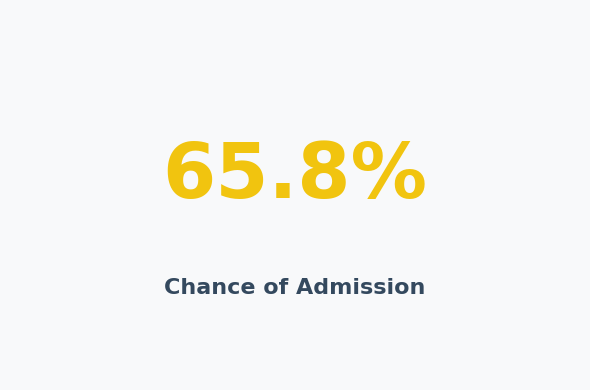

In [71]:
user_features = []
features_names = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research']

for feature in features_names:
    val = float(input(f"Enter {feature}: "))
    user_features.append(val)
    print(f"{feature}: {val}")

# Convert to DataFrame with feature names to avoid the UserWarning
user_df = pd.DataFrame([user_features], columns=features_names)

# Scale the input using the existing scaler object
user_features_scaled = scaler.transform(user_df)

# Coefficients and intercept provided
coef = np.array([0.02099652, 0.01639522, 0.00844812, -0.00029857, 0.01413835, 0.0673812, 0.01108222])
intercept = 0.7252812500000001

# Calculate the final prediction
prediction = np.dot(user_features_scaled[0], coef) + intercept

print(f"Predicted Chance of Admit: {prediction:.4f}")

if prediction >= 0.8:
    text_color = '#2ecc71'  # Green
elif prediction >= 0.65:
    text_color = '#f1c40f'  # Yellow/Gold
else:
    text_color = '#e74c3c'  # Red

# Visualizing the output beautifully inside matplotlib
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

# Main prediction text
ax.text(0.5, 0.55, f"{prediction:.1%}", fontsize=55, fontweight='bold', 
        color=text_color, ha='center', va='center')

# Label text
ax.text(0.5, 0.25, "Chance of Admission", fontsize=16, fontweight='semibold', 
        color='#34495e', ha='center', va='center')

plt.tight_layout()
plt.show()